In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
df = pd.read_csv("../data/processed/accidentes_2024_limpio.csv")

In [3]:
df.shape

(51762, 88)

In [4]:
df.head()

,ID_ACCIDENTE,ANYO,MES,DIA_SEMANA,HORA,COD_PROVINCIA,COD_MUNICIPIO,ZONA,ZONA_AGRUPADA,CARRETERA,...,NUDO_DESC,TIPO_ACCIDENTE_DESC,TIPO_VIA_DESC,REGISTRO_INCOMPLETO,DIA_SEMANA_DESC,FIN_SEMANA,FRANJA_HORARIA,ACCIDENTE_GRAVE,ACCIDENTE_MORTAL,TIENE_HERIDOS_GRAVES
0,10900,2024,1,1,3,8,8019,3,2,No inventariada,...,En intersección o nudo,Otro tipo de accidente,Otro,0,Lunes,0,Madrugada,0,0,0
1,10901,2024,1,1,2,8,8019,3,2,No inventariada,...,En intersección o nudo,Colisión contra obstáculo o elemento de la vía,Otro,0,Lunes,0,Madrugada,0,0,0
2,10902,2024,1,1,9,8,8019,3,2,No inventariada,...,En intersección o nudo,Lateral,Otro,0,Lunes,0,Mañana,0,0,0
3,10903,2024,1,1,3,8,8019,3,2,No inventariada,...,En intersección o nudo,Atropello a personas,Otro,0,Lunes,0,Madrugada,0,0,0
4,10904,2024,1,1,18,8,8019,3,2,No inventariada,...,Fuera de intersección o nudo,Otro tipo de accidente,Otro,0,Lunes,0,Noche,0,0,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51762 entries, 0 to 51761
Data columns (total 88 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID_ACCIDENTE              51762 non-null  int64  
 1   ANYO                      51762 non-null  int64  
 2   MES                       51762 non-null  int64  
 3   DIA_SEMANA                51762 non-null  int64  
 4   HORA                      51762 non-null  int64  
 5   COD_PROVINCIA             51762 non-null  int64  
 6   COD_MUNICIPIO             51762 non-null  int64  
 7   ZONA                      51762 non-null  int64  
 8   ZONA_AGRUPADA             51762 non-null  int64  
 9   CARRETERA                 51762 non-null  str    
 10  KM                        13086 non-null  float64
 11  SENTIDO_1F                51762 non-null  int64  
 12  TITULARIDAD_VIA           51762 non-null  int64  
 13  TIPO_VIA                  51762 non-null  int64  
 14  TIPO_ACCIDENTE   

In [6]:
df.describe(include="all")

,ID_ACCIDENTE,ANYO,MES,DIA_SEMANA,HORA,COD_PROVINCIA,COD_MUNICIPIO,ZONA,ZONA_AGRUPADA,CARRETERA,...,NUDO_DESC,TIPO_ACCIDENTE_DESC,TIPO_VIA_DESC,REGISTRO_INCOMPLETO,DIA_SEMANA_DESC,FIN_SEMANA,FRANJA_HORARIA,ACCIDENTE_GRAVE,ACCIDENTE_MORTAL,TIENE_HERIDOS_GRAVES
count,51762.000000,51762.0,51762.000000,51762.000000,51762.000000,51762.000000,51762.000000,51762.000000,51762.000000,51762,...,51762,51762,51762,51762.000000,51762,51762.000000,51762,51762.000000,51762.000000,51762.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1111,...,3,21,14,NaN,7,NaN,4,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No inventariada,...,Fuera de intersección o nudo,Fronto-lateral,Calle,NaN,Viernes,NaN,Tarde,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39007,...,26454,11633,26473,NaN,8398,NaN,19917,NaN,NaN,NaN
mean,51652.653298,2024.0,6.588965,3.823094,13.720683,24.520131,23704.171013,2.507167,1.760210,NaN,...,NaN,NaN,NaN,0.000135,NaN,0.230903,NaN,0.073452,0.007921,0.066709
std,26482.058599,0.0,3.439511,1.923746,5.367101,13.365833,13902.878986,0.854653,0.426959,NaN,...,NaN,NaN,NaN,0.011628,NaN,0.421415,NaN,0.260879,0.088647,0.249520
min,10900.000000,2024.0,1.000000,1.000000,0.000000,8.000000,0.000000,1.000000,1.000000,NaN,...,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,0.000000,0.000000,0.000000
25%,23840.250000,2024.0,4.000000,2.000000,10.000000,8.000000,8121.000000,2.000000,2.000000,NaN,...,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,0.000000,0.000000,0.000000
50%,55250.500000,2024.0,7.000000,4.000000,14.000000,28.000000,28079.000000,3.000000,2.000000,NaN,...,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,0.000000,0.000000,0.000000
75%,68191.750000,2024.0,10.000000,5.000000,18.000000,30.000000,30016.000000,3.000000,2.000000,NaN,...,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,0.000000,0.000000,0.000000


In [7]:
kpis = {
    "Accidentes": len(df),
    "Víctimas": df["TOTAL_VICTIMAS_24H"].sum(),
    "Fallecidos 24h": df["TOTAL_MU24H"].sum(),
    "Heridos graves 24h": df["TOTAL_HG24H"].sum(),
    "Heridos leves 24h": df["TOTAL_HL24H"].sum(),
    "Accidentes graves": df["ACCIDENTE_GRAVE"].sum(),
    "Accidentes mortales": df["ACCIDENTE_MORTAL"].sum()
}

kpis

{'Accidentes': 51762,
 'Víctimas': np.int64(67768),
 'Fallecidos 24h': np.int64(445),
 'Heridos graves 24h': np.int64(3763),
 'Heridos leves 24h': np.int64(63560),
 'Accidentes graves': np.int64(3802),
 'Accidentes mortales': np.int64(410)}

In [8]:
porcentaje_graves = df["ACCIDENTE_GRAVE"].mean() * 100
porcentaje_mortales = df["ACCIDENTE_MORTAL"].mean() * 100
victimas_por_accidente = df["TOTAL_VICTIMAS_24H"].mean()

porcentaje_graves, porcentaje_mortales, victimas_por_accidente

(np.float64(7.345156678644566),
 np.float64(0.7920868590858159),
 np.float64(1.3092229821104284))

In [9]:
accidentes_provincia = (
    df.groupby("PROVINCIA")
      .agg(
          ACCIDENTES=("ID_ACCIDENTE", "count"),
          VICTIMAS=("TOTAL_VICTIMAS_24H", "sum"),
          FALLECIDOS=("TOTAL_MU24H", "sum"),
          HERIDOS_GRAVES=("TOTAL_HG24H", "sum")
      )
      .sort_values("ACCIDENTES", ascending=False)
)

accidentes_provincia.head(10)

,ACCIDENTES,VICTIMAS,FALLECIDOS,HERIDOS_GRAVES
PROVINCIA,,,,
Barcelona,17945,23269,89,1259
Madrid,14183,18150,104,994
Valencia/València,5779,7099,60,483
Málaga,5185,7043,59,324
Sevilla,4748,6804,65,369
Murcia,3922,5403,68,334


In [10]:
tasas_provincia = (
    df.groupby("PROVINCIA")
      .agg(
          ACCIDENTES=("ID_ACCIDENTE", "count"),
          POBLACION=("POBLACION_2024", "first")
      )
)

tasas_provincia["TASA_ACCIDENTES_100K"] = (
    tasas_provincia["ACCIDENTES"] /
    tasas_provincia["POBLACION"] * 100000
)

tasas_provincia.sort_values(
    "TASA_ACCIDENTES_100K",
    ascending=False
)

,ACCIDENTES,POBLACION,TASA_ACCIDENTES_100K
PROVINCIA,,,
Barcelona,17945,5877672,305.307952
Málaga,5185,1774701,292.161891
Murcia,3922,1568492,250.049092
Sevilla,4748,1968624,241.183690
Valencia/València,5779,2710808,213.183671
Madrid,14183,7009268,202.346379


In [11]:
tasas_completas = (
    df.groupby("PROVINCIA")
      .agg(
          ACCIDENTES=("ID_ACCIDENTE", "count"),
          VICTIMAS=("TOTAL_VICTIMAS_24H", "sum"),
          FALLECIDOS=("TOTAL_MU24H", "sum"),
          HERIDOS_GRAVES=("TOTAL_HG24H", "sum"),
          POBLACION=("POBLACION_2024", "first")
      )
)

tasas_completas["TASA_ACCIDENTES_100K"] = (
    tasas_completas["ACCIDENTES"] / tasas_completas["POBLACION"] * 100000
)

tasas_completas["TASA_VICTIMAS_100K"] = (
    tasas_completas["VICTIMAS"] / tasas_completas["POBLACION"] * 100000
)

tasas_completas["TASA_FALLECIDOS_100K"] = (
    tasas_completas["FALLECIDOS"] / tasas_completas["POBLACION"] * 100000
)

tasas_completas["TASA_HERIDOS_GRAVES_100K"] = (
    tasas_completas["HERIDOS_GRAVES"] / tasas_completas["POBLACION"] * 100000
)

tasas_completas.round(2)

,ACCIDENTES,VICTIMAS,FALLECIDOS,HERIDOS_GRAVES,POBLACION,TASA_ACCIDENTES_100K,TASA_VICTIMAS_100K,TASA_FALLECIDOS_100K,TASA_HERIDOS_GRAVES_100K
PROVINCIA,,,,,,,,,
Barcelona,17945,23269,89,1259,5877672,305.31,395.89,1.51,21.42
Madrid,14183,18150,104,994,7009268,202.35,258.94,1.48,14.18
Murcia,3922,5403,68,334,1568492,250.05,344.47,4.34,21.29
Málaga,5185,7043,59,324,1774701,292.16,396.86,3.32,18.26
Sevilla,4748,6804,65,369,1968624,241.18,345.62,3.30,18.74
Valencia/València,5779,7099,60,483,2710808,213.18,261.88,2.21,17.82


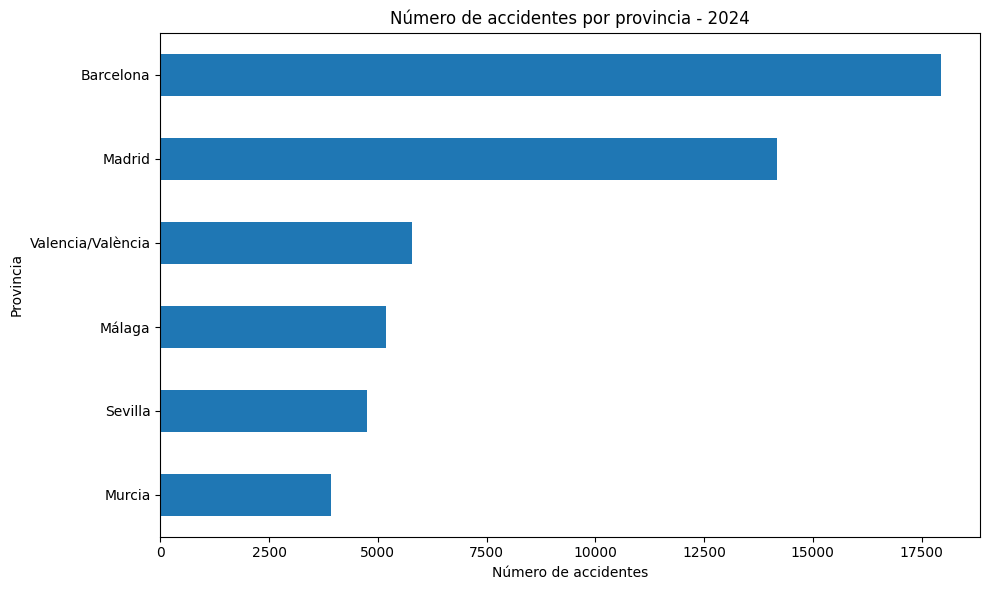

In [12]:
accidentes_grafico = (
    tasas_completas["ACCIDENTES"]
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

accidentes_grafico.plot(kind="barh")

plt.title("Número de accidentes por provincia - 2024")
plt.xlabel("Número de accidentes")
plt.ylabel("Provincia")

plt.tight_layout()
plt.show()

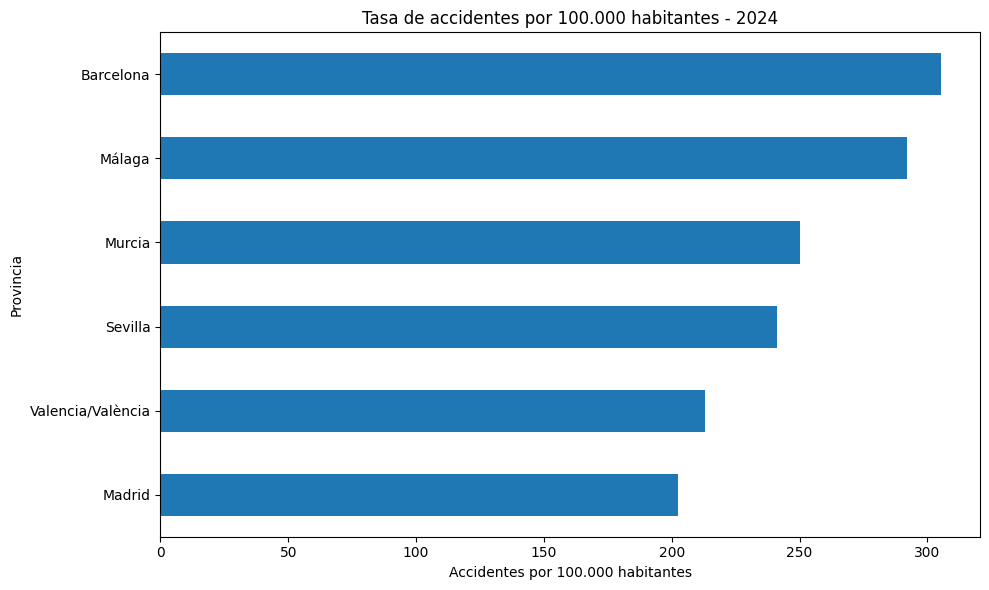

In [13]:
tasa_grafico = (
    tasas_completas["TASA_ACCIDENTES_100K"]
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

tasa_grafico.plot(kind="barh")

plt.title("Tasa de accidentes por 100.000 habitantes - 2024")
plt.xlabel("Accidentes por 100.000 habitantes")
plt.ylabel("Provincia")

plt.tight_layout()
plt.show()

In [14]:
accidentes_mes = (
    df.groupby("MES")["ID_ACCIDENTE"]
      .count()
      .sort_index()
)

accidentes_mes

MES
1     3986
2     4122
3     4113
4     4381
5     4601
6     4504
7     4560
8     3463
9     4368
10    4788
11    4392
12    4484
Name: ID_ACCIDENTE, dtype: int64

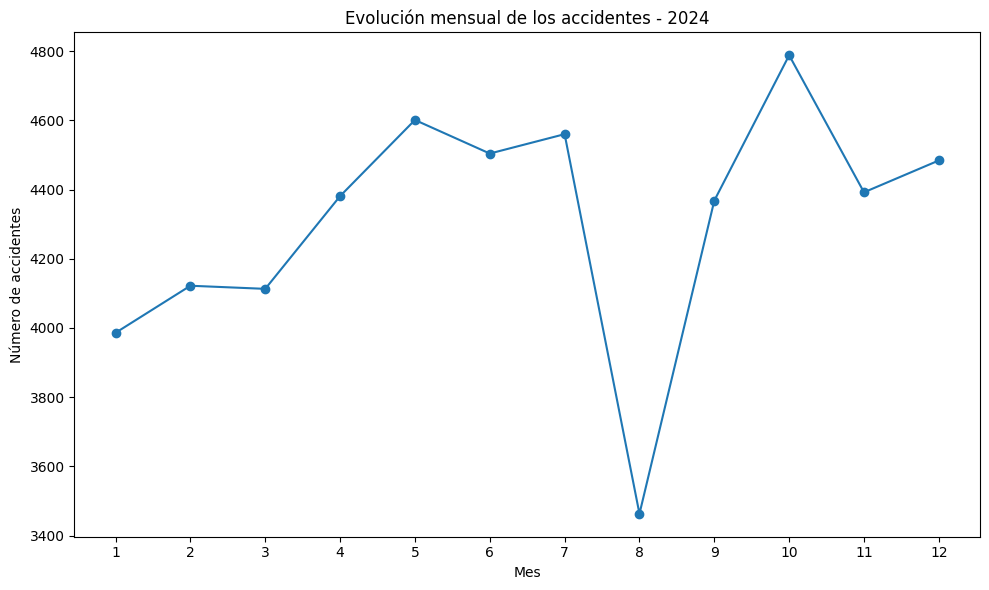

In [15]:
plt.figure(figsize=(10, 6))

accidentes_mes.plot(marker="o")

plt.title("Evolución mensual de los accidentes - 2024")
plt.xlabel("Mes")
plt.ylabel("Número de accidentes")
plt.xticks(range(1, 13))

plt.tight_layout()

plt.savefig(
    "../images/accidentes_por_mes_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
accidentes_dia = (
    df.groupby("DIA_SEMANA")["ID_ACCIDENTE"]
      .count()
      .sort_index()
)

accidentes_dia

DIA_SEMANA
1    7864
2    7781
3    7766
4    8001
5    8398
6    6491
7    5461
Name: ID_ACCIDENTE, dtype: int64

In [17]:
df[["DIA_SEMANA", "DIA_SEMANA_DESC"]].drop_duplicates().sort_values("DIA_SEMANA")

,DIA_SEMANA,DIA_SEMANA_DESC
0,1,Lunes
14,2,Martes
26,3,Miércoles
33,4,Jueves
56,5,Viernes
62,6,Sábado
94,7,Domingo


In [18]:
orden_dias = [
    "Lunes",
    "Martes",
    "Miércoles",
    "Jueves",
    "Viernes",
    "Sábado",
    "Domingo"
]

accidentes_dia_nombre = (
    df.groupby("DIA_SEMANA_DESC")["ID_ACCIDENTE"]
      .count()
      .reindex(orden_dias)
)

accidentes_dia_nombre

DIA_SEMANA_DESC
Lunes        7864
Martes       7781
Miércoles    7766
Jueves       8001
Viernes      8398
Sábado       6491
Domingo      5461
Name: ID_ACCIDENTE, dtype: int64

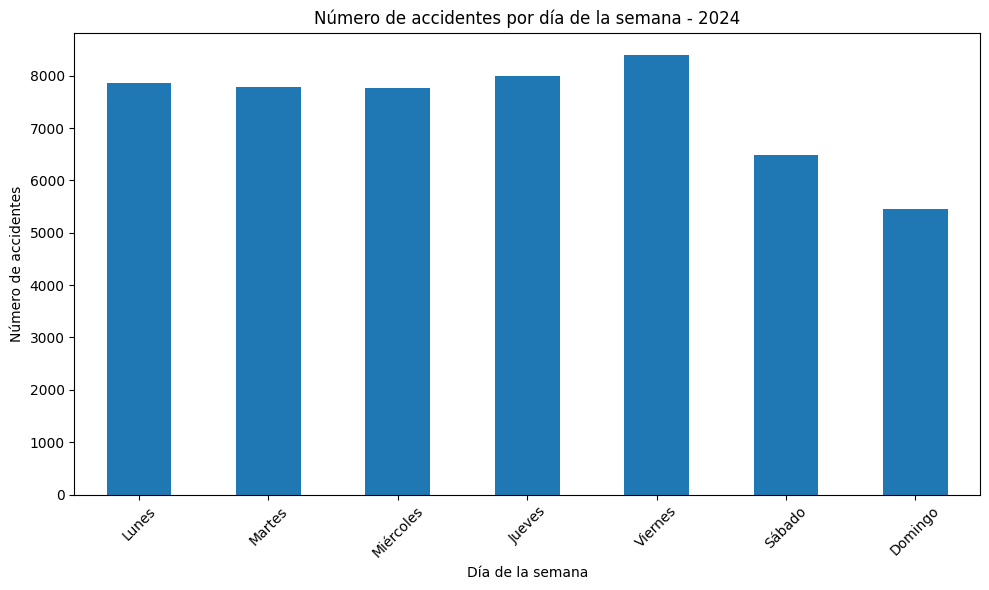

In [19]:
plt.figure(figsize=(10, 6))

accidentes_dia_nombre.plot(kind="bar")

plt.title("Número de accidentes por día de la semana - 2024")
plt.xlabel("Día de la semana")
plt.ylabel("Número de accidentes")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../images/accidentes_por_dia_semana_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
accidentes_hora = (
    df.groupby("HORA")["ID_ACCIDENTE"]
      .count()
      .sort_index()
)

accidentes_hora

HORA
0      917
1      638
2      436
3      405
4      377
5      546
6     1062
7     2013
8     2692
9     2761
10    2435
11    2842
12    3195
13    3543
14    3942
15    3355
16    2769
17    3113
18    3440
19    3245
20    2887
21    2166
22    1760
23    1223
Name: ID_ACCIDENTE, dtype: int64

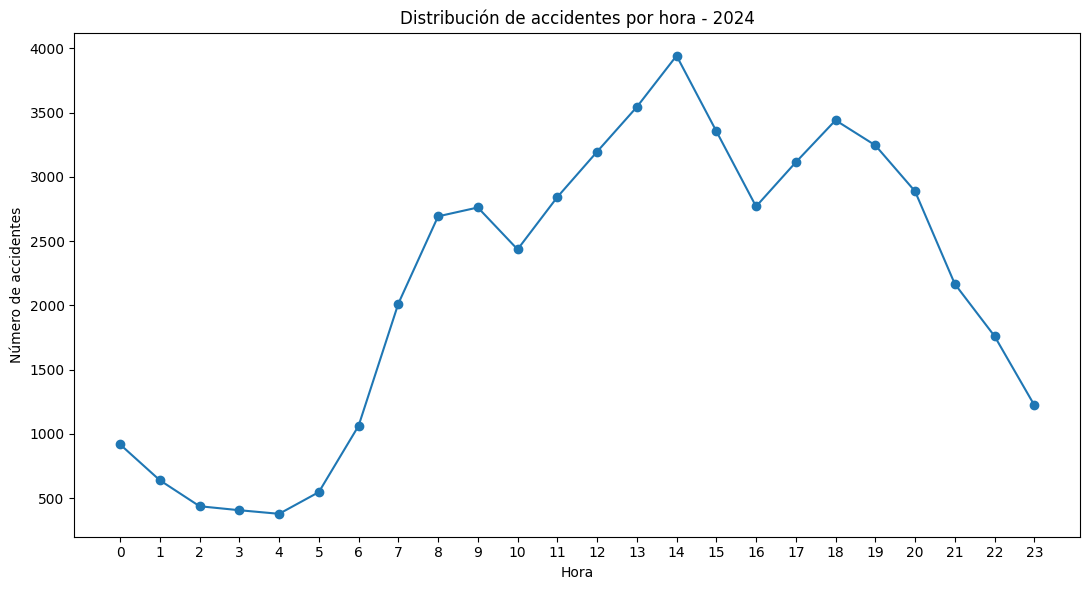

In [21]:
plt.figure(figsize=(11, 6))

accidentes_hora.plot(marker="o")

plt.title("Distribución de accidentes por hora - 2024")
plt.xlabel("Hora")
plt.ylabel("Número de accidentes")
plt.xticks(range(0, 24))

plt.tight_layout()

plt.savefig(
    "../images/accidentes_por_hora_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

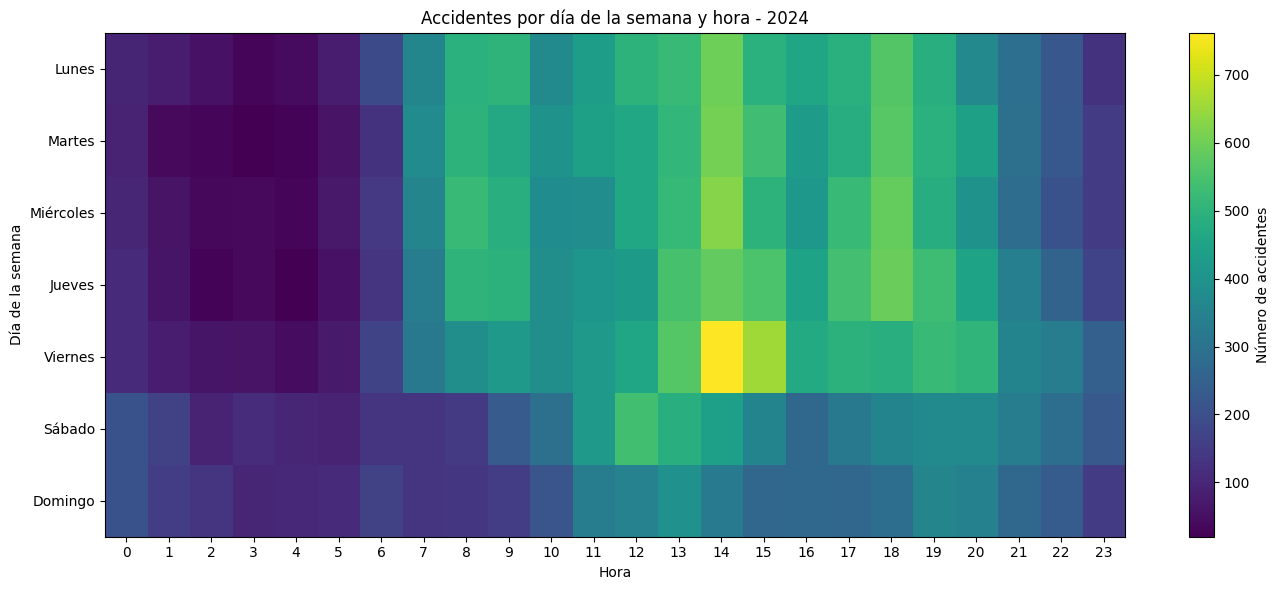

In [22]:
tabla_dia_hora = pd.crosstab(
    df["DIA_SEMANA_DESC"],
    df["HORA"]
).reindex(orden_dias)

plt.figure(figsize=(14, 6))

plt.imshow(
    tabla_dia_hora,
    aspect="auto"
)

plt.title("Accidentes por día de la semana y hora - 2024")
plt.xlabel("Hora")
plt.ylabel("Día de la semana")

plt.xticks(
    ticks=range(24),
    labels=range(24)
)

plt.yticks(
    ticks=range(len(orden_dias)),
    labels=orden_dias
)

plt.colorbar(label="Número de accidentes")

plt.tight_layout()

plt.savefig(
    "../images/heatmap_dia_hora_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
maximo_dia_hora = tabla_dia_hora.stack().idxmax()
valor_maximo_dia_hora = tabla_dia_hora.stack().max()

maximo_dia_hora, valor_maximo_dia_hora

(('Viernes', np.int64(14)), np.int64(762))

In [24]:
gravedad_hora = (
    df.groupby("HORA")
      .agg(
          ACCIDENTES=("ID_ACCIDENTE", "count"),
          ACCIDENTES_GRAVES=("ACCIDENTE_GRAVE", "sum"),
          ACCIDENTES_MORTALES=("ACCIDENTE_MORTAL", "sum")
      )
)

gravedad_hora["PORC_GRAVES"] = (
    gravedad_hora["ACCIDENTES_GRAVES"] /
    gravedad_hora["ACCIDENTES"] * 100
)

gravedad_hora["PORC_MORTALES"] = (
    gravedad_hora["ACCIDENTES_MORTALES"] /
    gravedad_hora["ACCIDENTES"] * 100
)

gravedad_hora.round(2)

,ACCIDENTES,ACCIDENTES_GRAVES,ACCIDENTES_MORTALES,PORC_GRAVES,PORC_MORTALES
HORA,,,,,
0,917,92,14,10.03,1.53
1,638,67,11,10.50,1.72
2,436,73,17,16.74,3.90
3,405,50,10,12.35,2.47
4,377,53,13,14.06,3.45
5,546,54,9,9.89,1.65
6,1062,121,16,11.39,1.51
7,2013,148,16,7.35,0.79
8,2692,187,17,6.95,0.63


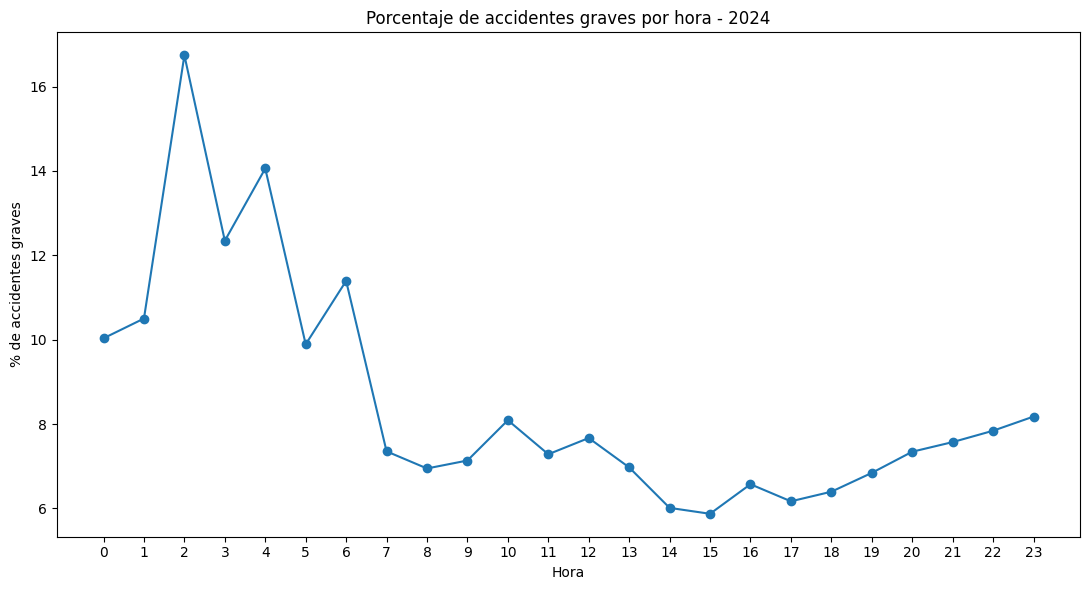

In [25]:
plt.figure(figsize=(11, 6))

gravedad_hora["PORC_GRAVES"].plot(marker="o")

plt.title("Porcentaje de accidentes graves por hora - 2024")
plt.xlabel("Hora")
plt.ylabel("% de accidentes graves")
plt.xticks(range(0, 24))

plt.tight_layout()

plt.savefig(
    "../images/porcentaje_graves_por_hora_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

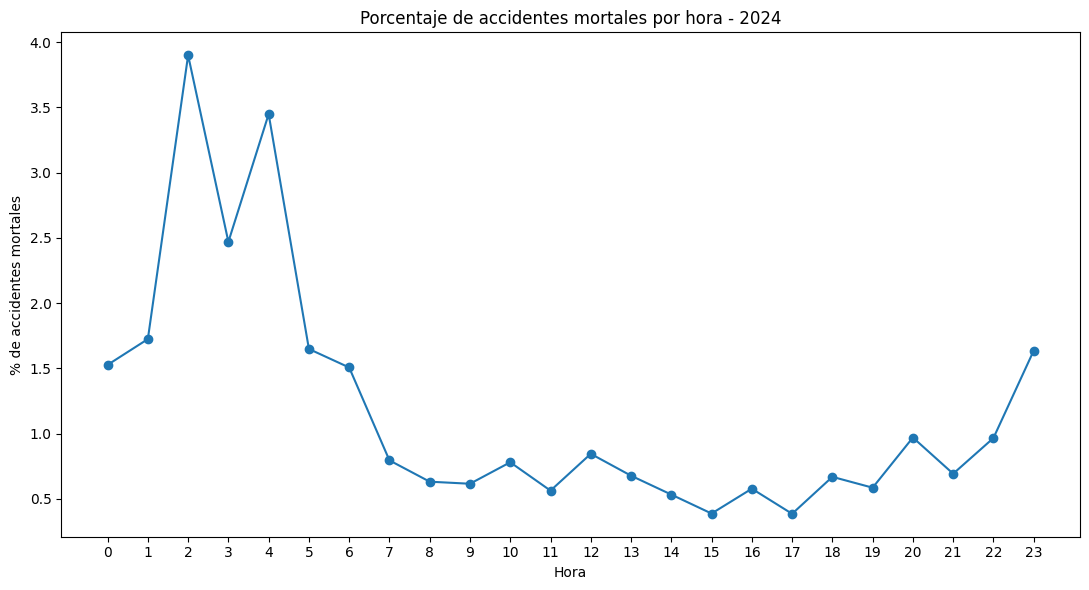

In [26]:
plt.figure(figsize=(11, 6))

gravedad_hora["PORC_MORTALES"].plot(marker="o")

plt.title("Porcentaje de accidentes mortales por hora - 2024")
plt.xlabel("Hora")
plt.ylabel("% de accidentes mortales")
plt.xticks(range(0, 24))

plt.tight_layout()

plt.savefig(
    "../images/porcentaje_mortales_por_hora_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
gravedad_dia = (
    df.groupby("DIA_SEMANA_DESC")
      .agg(
          ACCIDENTES=("ID_ACCIDENTE", "count"),
          ACCIDENTES_GRAVES=("ACCIDENTE_GRAVE", "sum"),
          ACCIDENTES_MORTALES=("ACCIDENTE_MORTAL", "sum")
      )
      .reindex(orden_dias)
)

gravedad_dia["PORC_GRAVES"] = (
    gravedad_dia["ACCIDENTES_GRAVES"] /
    gravedad_dia["ACCIDENTES"] * 100
)

gravedad_dia["PORC_MORTALES"] = (
    gravedad_dia["ACCIDENTES_MORTALES"] /
    gravedad_dia["ACCIDENTES"] * 100
)

gravedad_dia.round(2)

,ACCIDENTES,ACCIDENTES_GRAVES,ACCIDENTES_MORTALES,PORC_GRAVES,PORC_MORTALES
DIA_SEMANA_DESC,,,,,
Lunes,7864,569,63,7.24,0.80
Martes,7781,501,45,6.44,0.58
Miércoles,7766,530,44,6.82,0.57
Jueves,8001,513,35,6.41,0.44
Viernes,8398,572,65,6.81,0.77
Sábado,6491,607,88,9.35,1.36
Domingo,5461,510,70,9.34,1.28


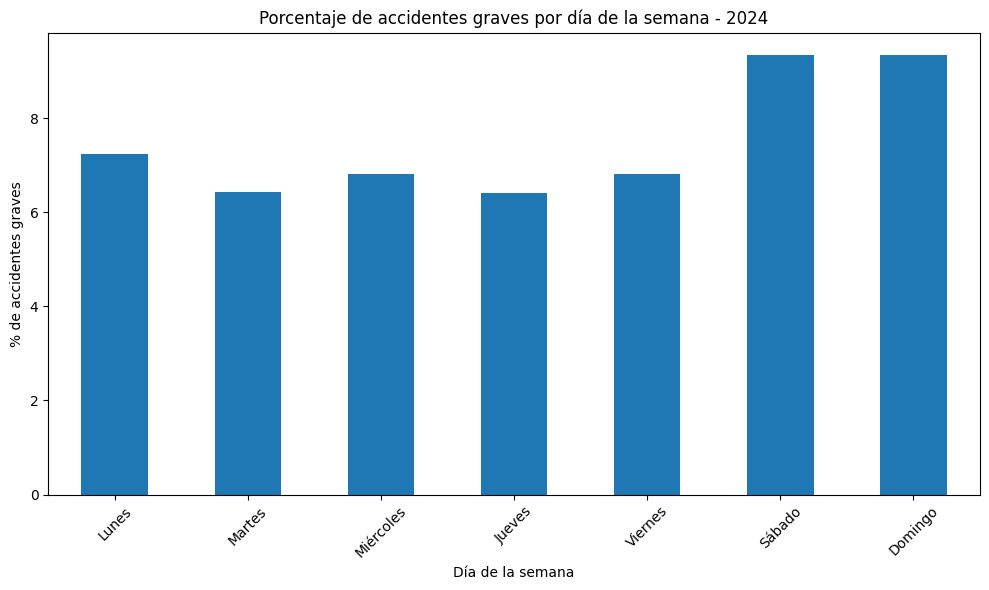

In [28]:
plt.figure(figsize=(10, 6))

gravedad_dia["PORC_GRAVES"].plot(kind="bar")

plt.title("Porcentaje de accidentes graves por día de la semana - 2024")
plt.xlabel("Día de la semana")
plt.ylabel("% de accidentes graves")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../images/porcentaje_graves_por_dia_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

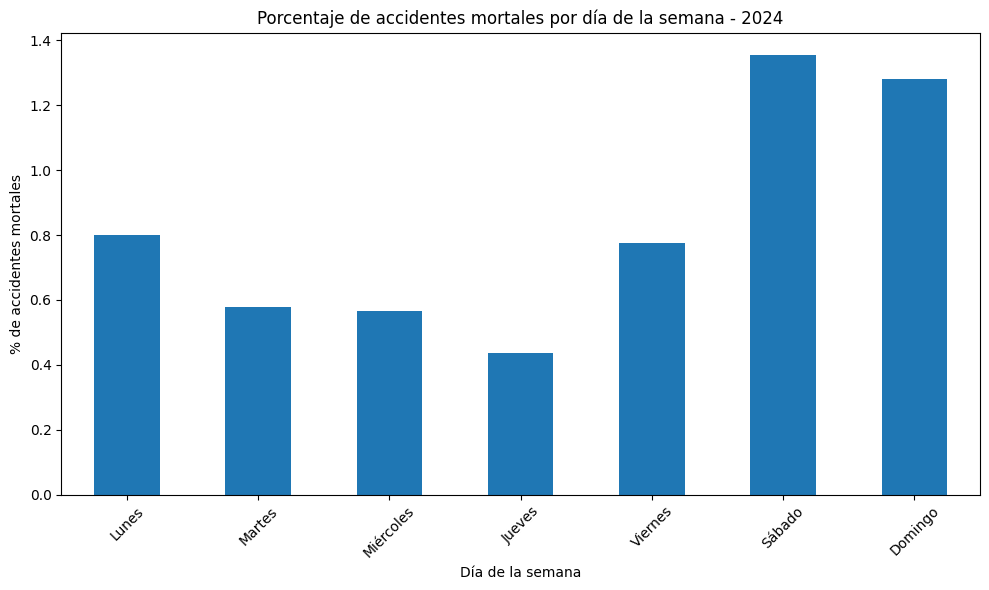

In [29]:
plt.figure(figsize=(10, 6))

gravedad_dia["PORC_MORTALES"].plot(kind="bar")

plt.title("Porcentaje de accidentes mortales por día de la semana - 2024")
plt.xlabel("Día de la semana")
plt.ylabel("% de accidentes mortales")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../images/porcentaje_mortales_por_dia_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
df[["ZONA", "ZONA_DESC"]].drop_duplicates().sort_values("ZONA")

,ZONA,ZONA_DESC
6,1,Carretera
20,2,Travesía
0,3,Calle
166,4,Autopista o autovía urbana


In [31]:
gravedad_zona = (
    df.groupby("ZONA_DESC")
      .agg(
          ACCIDENTES=("ID_ACCIDENTE", "count"),
          ACCIDENTES_GRAVES=("ACCIDENTE_GRAVE", "sum"),
          ACCIDENTES_MORTALES=("ACCIDENTE_MORTAL", "sum"),
          VICTIMAS=("TOTAL_VICTIMAS_24H", "sum"),
          FALLECIDOS=("TOTAL_MU24H", "sum")
      )
)

gravedad_zona["PORC_GRAVES"] = (
    gravedad_zona["ACCIDENTES_GRAVES"] /
    gravedad_zona["ACCIDENTES"] * 100
)

gravedad_zona["PORC_MORTALES"] = (
    gravedad_zona["ACCIDENTES_MORTALES"] /
    gravedad_zona["ACCIDENTES"] * 100
)

gravedad_zona.round(2)

,ACCIDENTES,ACCIDENTES_GRAVES,ACCIDENTES_MORTALES,VICTIMAS,FALLECIDOS,PORC_GRAVES,PORC_MORTALES
ZONA_DESC,,,,,,,
Autopista o autovía urbana,23,1,1,27,1,4.35,4.35
Calle,38618,2407,135,47926,137,6.23,0.35
Carretera,12412,1324,269,18922,301,10.67,2.17
Travesía,709,70,5,893,6,9.87,0.71


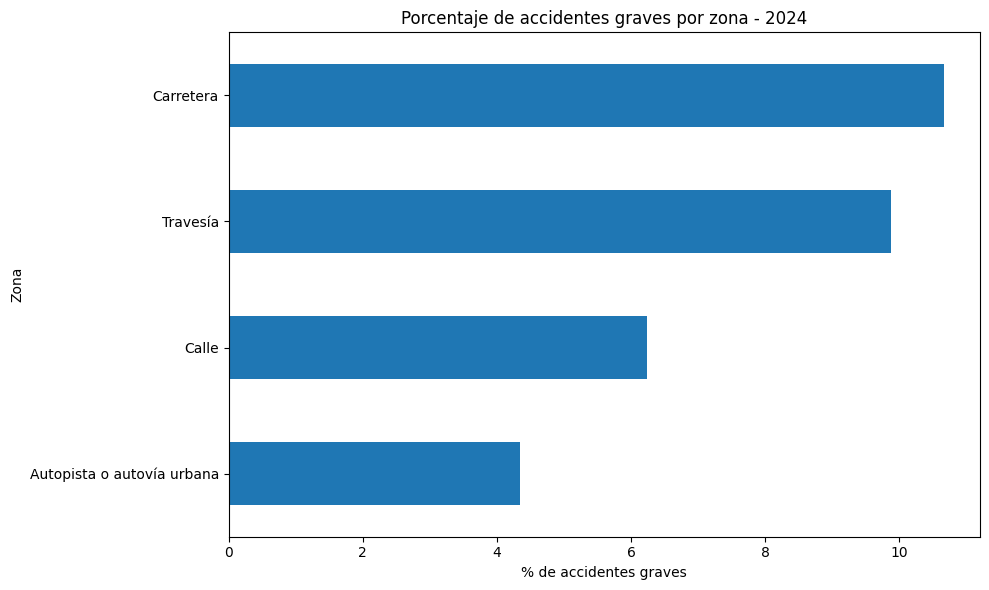

In [32]:
plt.figure(figsize=(10, 6))

gravedad_zona["PORC_GRAVES"].sort_values().plot(kind="barh")

plt.title("Porcentaje de accidentes graves por zona - 2024")
plt.xlabel("% de accidentes graves")
plt.ylabel("Zona")

plt.tight_layout()

plt.savefig(
    "../images/porcentaje_graves_por_zona_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

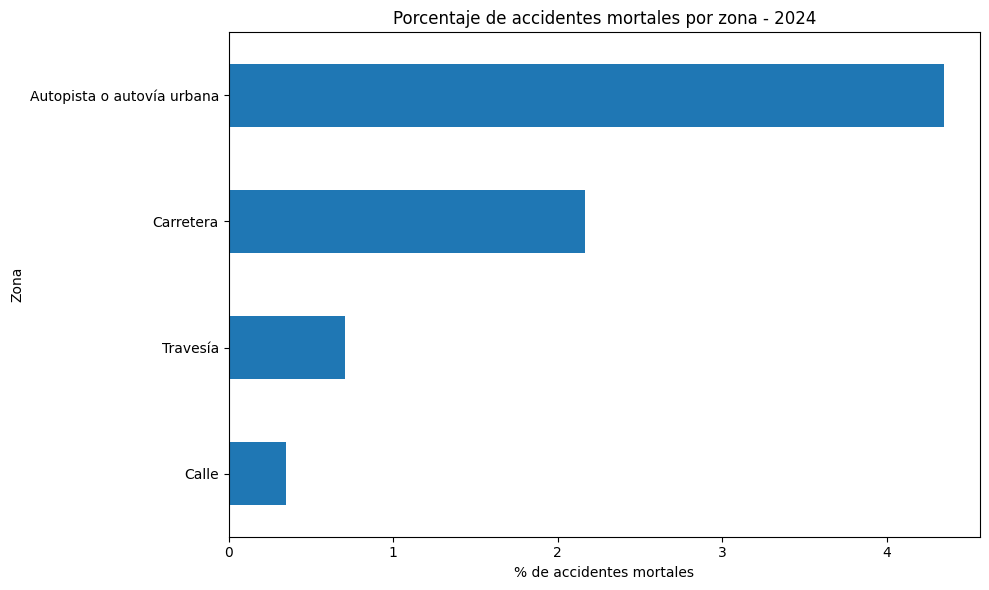

In [33]:
plt.figure(figsize=(10, 6))

gravedad_zona["PORC_MORTALES"].sort_values().plot(kind="barh")

plt.title("Porcentaje de accidentes mortales por zona - 2024")
plt.xlabel("% de accidentes mortales")
plt.ylabel("Zona")

plt.tight_layout()

plt.savefig(
    "../images/porcentaje_mortales_por_zona_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [34]:
df[["TIPO_VIA", "TIPO_VIA_DESC"]].drop_duplicates().sort_values("TIPO_VIA")

,TIPO_VIA,TIPO_VIA_DESC
18054,1,Autopista de peaje
11,2,Autopista libre
7,3,Autovía
23561,4,Vía para automóviles
17964,5,Carretera Convencional de doble calzada
6,6,Carretera Convencional de calzada única
17961,7,Vía de servicio
18053,8,Ramal de enlace
17955,9,Calle
30777,10,Camino vecinal


In [36]:
gravedad_tipo_via = (
    df.groupby("TIPO_VIA_DESC")
      .agg(
          ACCIDENTES=("ID_ACCIDENTE", "count"),
          ACCIDENTES_GRAVES=("ACCIDENTE_GRAVE", "sum"),
          ACCIDENTES_MORTALES=("ACCIDENTE_MORTAL", "sum"),
          VICTIMAS=("TOTAL_VICTIMAS_24H", "sum"),
          FALLECIDOS=("TOTAL_MU24H", "sum")
      )
)

gravedad_tipo_via["PORC_GRAVES"] = (
    gravedad_tipo_via["ACCIDENTES_GRAVES"] /
    gravedad_tipo_via["ACCIDENTES"] * 100
)

gravedad_tipo_via["PORC_MORTALES"] = (
    gravedad_tipo_via["ACCIDENTES_MORTALES"] /
    gravedad_tipo_via["ACCIDENTES"] * 100
)

gravedad_tipo_via.sort_values("ACCIDENTES", ascending=False).round(2)

,ACCIDENTES,ACCIDENTES_GRAVES,ACCIDENTES_MORTALES,VICTIMAS,FALLECIDOS,PORC_GRAVES,PORC_MORTALES
TIPO_VIA_DESC,,,,,,,
Calle,26473,1624,102,33214,104,6.13,0.39
Otro,13070,851,37,15977,37,6.51,0.28
Carretera Convencional de calzada única,5228,671,121,7596,134,12.83,2.31
Autovía,3937,383,96,6247,105,9.73,2.44
Autopista libre,1989,152,25,3265,30,7.64,1.26
Carretera Convencional de doble calzada,565,52,11,778,15,9.20,1.95
Camino vecinal,166,32,7,244,8,19.28,4.22
Vía de servicio,110,10,3,145,3,9.09,2.73
Ramal de enlace,95,8,2,116,2,8.42,2.11


In [37]:
tipo_via_relevante = (
    gravedad_tipo_via[
        gravedad_tipo_via["ACCIDENTES"] >= 500
    ]
    .sort_values("PORC_GRAVES", ascending=True)
)

tipo_via_relevante.round(2)

,ACCIDENTES,ACCIDENTES_GRAVES,ACCIDENTES_MORTALES,VICTIMAS,FALLECIDOS,PORC_GRAVES,PORC_MORTALES
TIPO_VIA_DESC,,,,,,,
Calle,26473,1624,102,33214,104,6.13,0.39
Otro,13070,851,37,15977,37,6.51,0.28
Autopista libre,1989,152,25,3265,30,7.64,1.26
Carretera Convencional de doble calzada,565,52,11,778,15,9.20,1.95
Autovía,3937,383,96,6247,105,9.73,2.44
Carretera Convencional de calzada única,5228,671,121,7596,134,12.83,2.31


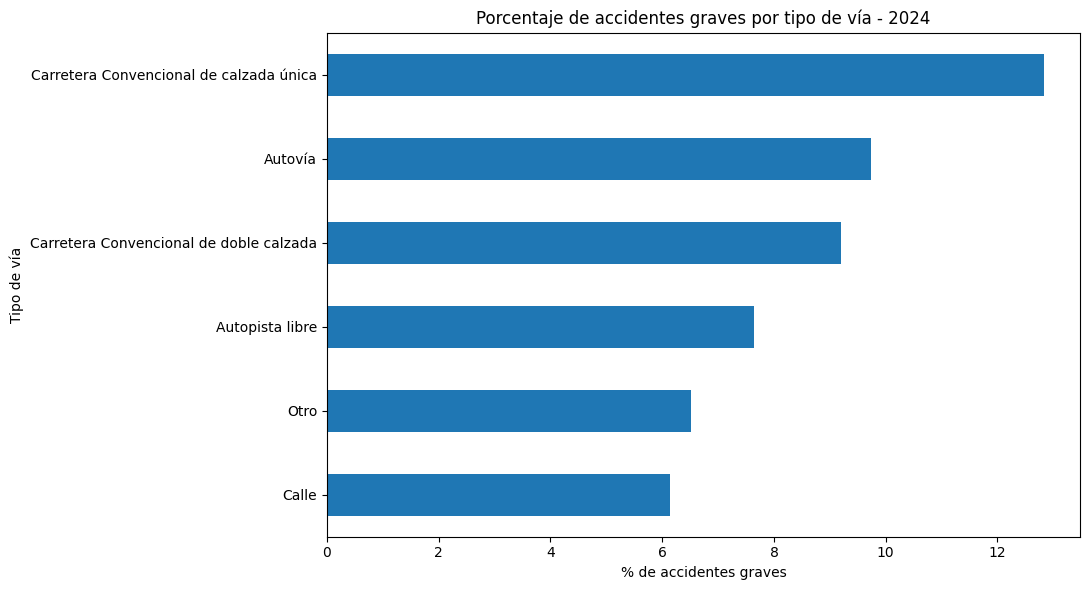

In [38]:
plt.figure(figsize=(11, 6))

tipo_via_relevante["PORC_GRAVES"].plot(kind="barh")

plt.title("Porcentaje de accidentes graves por tipo de vía - 2024")
plt.xlabel("% de accidentes graves")
plt.ylabel("Tipo de vía")

plt.tight_layout()

plt.savefig(
    "../images/porcentaje_graves_por_tipo_via_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

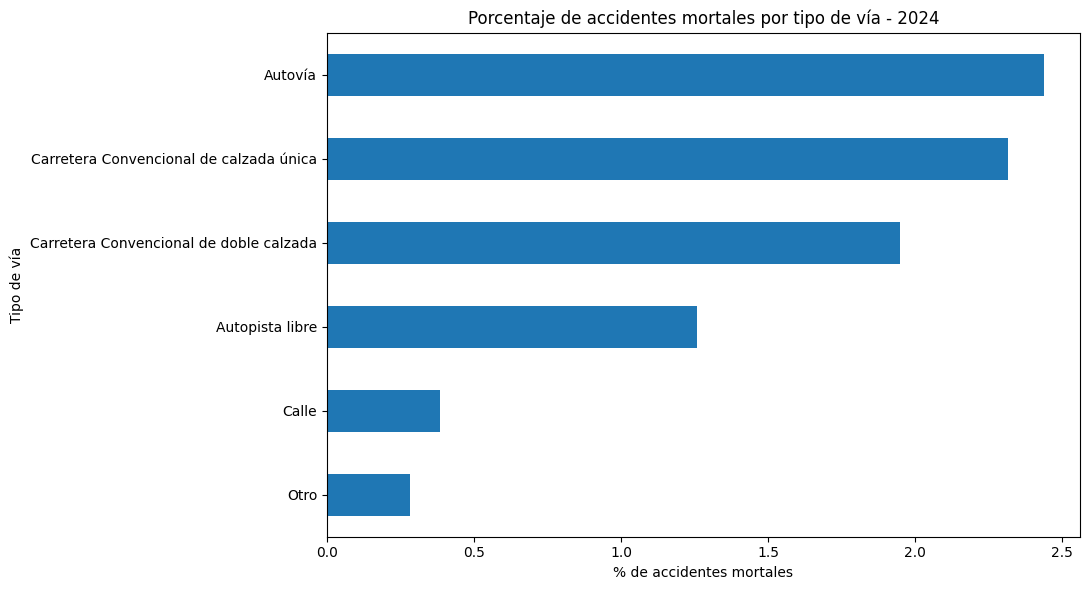

In [39]:
tipo_via_mortal = (
    gravedad_tipo_via[
        gravedad_tipo_via["ACCIDENTES"] >= 500
    ]
    .sort_values("PORC_MORTALES", ascending=True)
)

plt.figure(figsize=(11, 6))

tipo_via_mortal["PORC_MORTALES"].plot(kind="barh")

plt.title("Porcentaje de accidentes mortales por tipo de vía - 2024")
plt.xlabel("% de accidentes mortales")
plt.ylabel("Tipo de vía")

plt.tight_layout()

plt.savefig(
    "../images/porcentaje_mortales_por_tipo_via_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [40]:
df[["TIPO_ACCIDENTE", "TIPO_ACCIDENTE_DESC"]].drop_duplicates().sort_values("TIPO_ACCIDENTE")

,TIPO_ACCIDENTE,TIPO_ACCIDENTE_DESC
57,1.0,Frontal
18,2.0,Fronto-lateral
2,3.0,Lateral
11,4.0,Por alcance
17962,5.0,Múltiple o en caravana
1,6.0,Colisión contra obstáculo o elemento de la vía
3,7.0,Atropello a personas
130,8.0,Atropello a animales
5,9.0,Vuelco
17947,10.0,Caída


In [41]:
gravedad_tipo_accidente = (
    df.groupby("TIPO_ACCIDENTE_DESC")
      .agg(
          ACCIDENTES=("ID_ACCIDENTE", "count"),
          ACCIDENTES_GRAVES=("ACCIDENTE_GRAVE", "sum"),
          ACCIDENTES_MORTALES=("ACCIDENTE_MORTAL", "sum"),
          VICTIMAS=("TOTAL_VICTIMAS_24H", "sum"),
          FALLECIDOS=("TOTAL_MU24H", "sum")
      )
)

gravedad_tipo_accidente["PORC_GRAVES"] = (
    gravedad_tipo_accidente["ACCIDENTES_GRAVES"] /
    gravedad_tipo_accidente["ACCIDENTES"] * 100
)

gravedad_tipo_accidente["PORC_MORTALES"] = (
    gravedad_tipo_accidente["ACCIDENTES_MORTALES"] /
    gravedad_tipo_accidente["ACCIDENTES"] * 100
)

gravedad_tipo_accidente.sort_values(
    "ACCIDENTES",
    ascending=False
).round(2)

,ACCIDENTES,ACCIDENTES_GRAVES,ACCIDENTES_MORTALES,VICTIMAS,FALLECIDOS,PORC_GRAVES,PORC_MORTALES
TIPO_ACCIDENTE_DESC,,,,,,,
Fronto-lateral,11633,782,24,15196,27,6.72,0.21
Por alcance,9145,378,51,13802,52,4.13,0.56
Atropello a personas,6206,800,94,6998,95,12.89,1.51
Lateral,5467,260,18,6772,18,4.76,0.33
Caída,4646,254,6,4974,6,5.47,0.13
Otro tipo de accidente,3313,157,16,4410,18,4.74,0.48
Vuelco,2487,178,11,2756,11,7.16,0.44
Salida de la vía por la derecha otro tipo,1706,156,27,2149,27,9.14,1.58
Colisión contra obstáculo o elemento de la vía,1439,127,18,1766,24,8.83,1.25


In [42]:
tipo_accidente_relevante = (
    gravedad_tipo_accidente[
        gravedad_tipo_accidente["ACCIDENTES"] >= 500
    ]
    .sort_values("PORC_GRAVES", ascending=True)
)

tipo_accidente_relevante.round(2)

,ACCIDENTES,ACCIDENTES_GRAVES,ACCIDENTES_MORTALES,VICTIMAS,FALLECIDOS,PORC_GRAVES,PORC_MORTALES
TIPO_ACCIDENTE_DESC,,,,,,,
Por alcance,9145,378,51,13802,52,4.13,0.56
Otro tipo de accidente,3313,157,16,4410,18,4.74,0.48
Lateral,5467,260,18,6772,18,4.76,0.33
Múltiple o en caravana,945,45,6,1982,8,4.76,0.63
Caída,4646,254,6,4974,6,5.47,0.13
Fronto-lateral,11633,782,24,15196,27,6.72,0.21
Vuelco,2487,178,11,2756,11,7.16,0.44
Colisión contra obstáculo o elemento de la vía,1439,127,18,1766,24,8.83,1.25
Salida de la vía por la derecha otro tipo,1706,156,27,2149,27,9.14,1.58


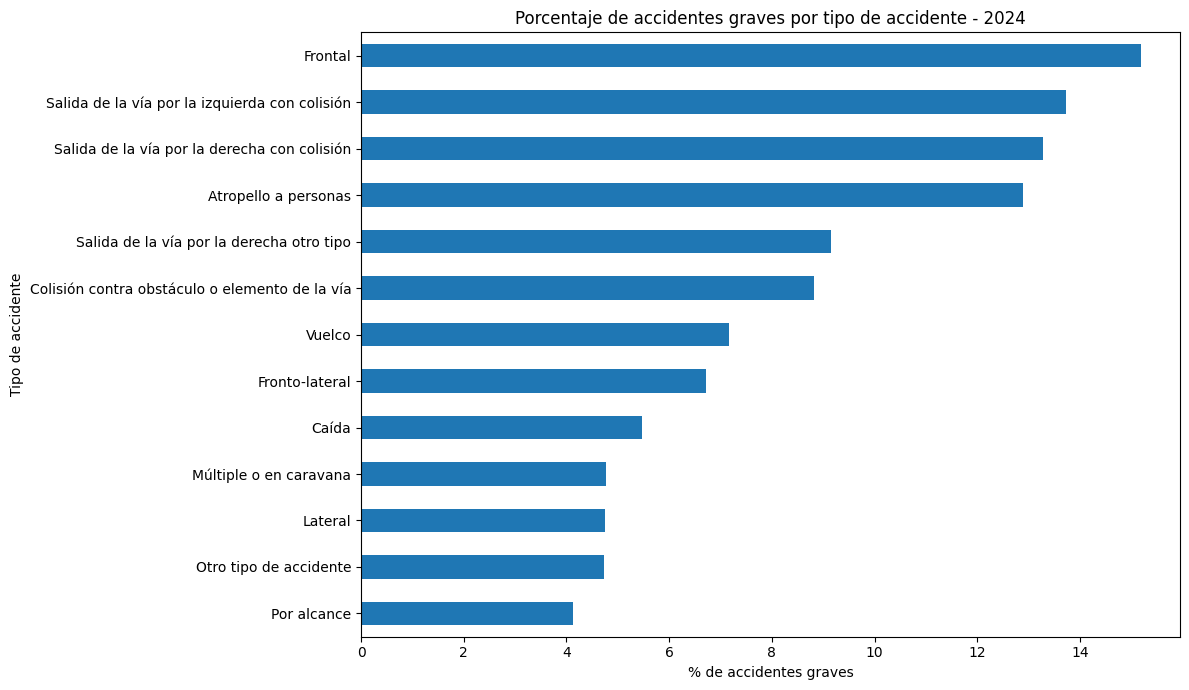

In [43]:
plt.figure(figsize=(12, 7))

tipo_accidente_relevante["PORC_GRAVES"].plot(kind="barh")

plt.title("Porcentaje de accidentes graves por tipo de accidente - 2024")
plt.xlabel("% de accidentes graves")
plt.ylabel("Tipo de accidente")

plt.tight_layout()

plt.savefig(
    "../images/porcentaje_graves_por_tipo_accidente_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

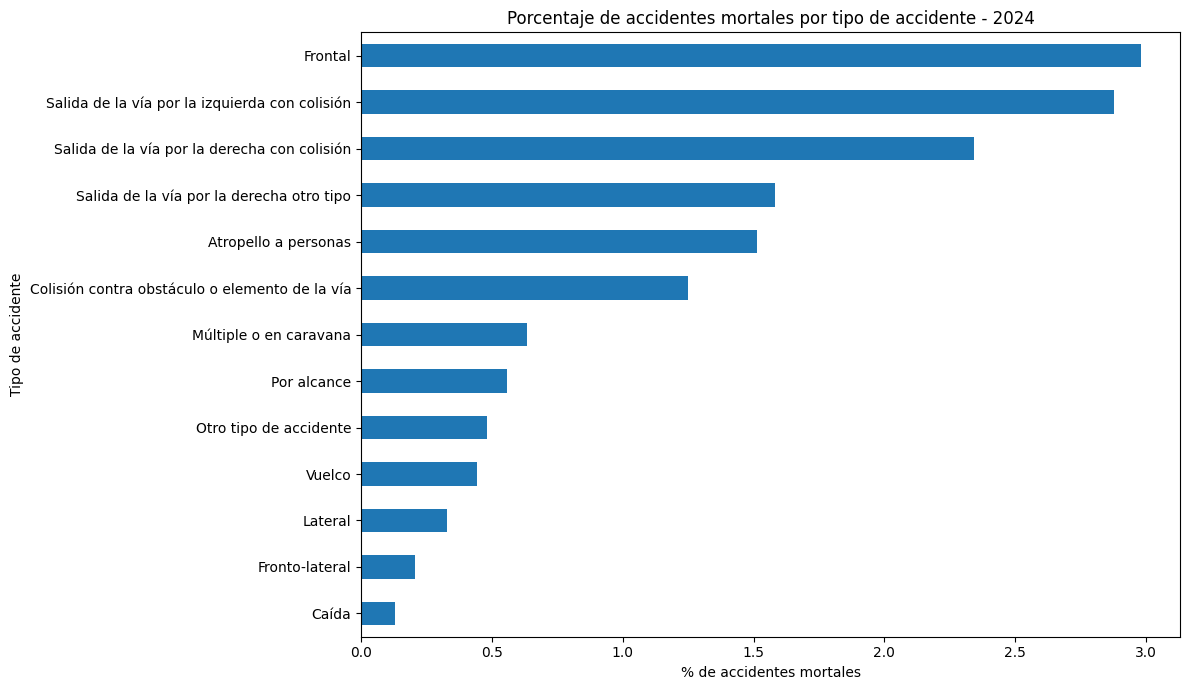

In [44]:
tipo_accidente_mortal = (
    gravedad_tipo_accidente[
        gravedad_tipo_accidente["ACCIDENTES"] >= 500
    ]
    .sort_values("PORC_MORTALES", ascending=True)
)

plt.figure(figsize=(12, 7))

tipo_accidente_mortal["PORC_MORTALES"].plot(kind="barh")

plt.title("Porcentaje de accidentes mortales por tipo de accidente - 2024")
plt.xlabel("% de accidentes mortales")
plt.ylabel("Tipo de accidente")

plt.tight_layout()

plt.savefig(
    "../images/porcentaje_mortales_por_tipo_accidente_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()